In [2]:
"""
Psi4 Environment Diagnostic Script
====================================
Tests progressively more complex calculations to pinpoint
where your environment breaks. Run and share the output.
"""

import sys

# ─────────────────────────────────────────────
# TEST 0 — Python & import check
# ─────────────────────────────────────────────
print("=" * 55)
print("TEST 0: Python environment")
print("=" * 55)
print(f"  Python version : {sys.version}")

try:
    import psi4
    print(f"  Psi4 version   : {psi4.__version__}")
    print("  [PASS] psi4 imported successfully\n")
except ImportError as e:
    print(f"  [FAIL] Cannot import psi4: {e}")
    sys.exit(1)

try:
    import numpy as np
    print(f"  NumPy version  : {np.__version__}")
    print("  [PASS] numpy imported successfully\n")
except ImportError as e:
    print(f"  [FAIL] Cannot import numpy: {e}\n")

# ─────────────────────────────────────────────
# Psi4 basic config
# ─────────────────────────────────────────────
psi4.set_memory("2 GB")
psi4.set_num_threads(2)
psi4.set_output_file("psi4_env_check.out", False)
psi4.core.clean()
psi4.core.clean_options()

# ─────────────────────────────────────────────
# TEST 1 — Minimal RHF: water (closed-shell, singlet)
# ─────────────────────────────────────────────
print("=" * 55)
print("TEST 1: Minimal RHF — water / STO-3G (singlet)")
print("=" * 55)
try:
    psi4.set_options({"basis": "STO-3G", "reference": "rhf",
                      "scf_type": "pk", "e_convergence": 1e-6})
    water = psi4.geometry("""
    0 1
    O  0.000000  0.000000  0.117000
    H  0.000000  0.757000 -0.468000
    H  0.000000 -0.757000 -0.468000
    units angstrom
    symmetry c1
    """)
    e_water = psi4.energy("hf", molecule=water)
    print(f"  E(HF/STO-3G) = {e_water:.8f} Hartree")
    print("  [PASS] RHF singlet works\n")
except Exception as e:
    print(f"  [FAIL] RHF singlet failed: {e}\n")


# ─────────────────────────────────────────────
# TEST 2 — DFT open-shell: Br+ cation alone
#           charge=+1, mult=3, needs UKS
# ─────────────────────────────────────────────
print("=" * 55)
print("TEST 2: DFT B3LYP — Br+ cation / def2-SVP (triplet, charge=+1)")
print("=" * 55)
try:
    psi4.set_options({"basis": "def2-SVP", "reference": "uks",
                      "scf_type": "df", "e_convergence": 1e-6})
    br_cation = psi4.geometry("""
    1 3
    Br  0.000000  0.000000  0.000000
    units angstrom
    symmetry c1
    """)
    e_br = psi4.energy("b3lyp", molecule=br_cation)
    print(f"  E(UKS B3LYP/def2-SVP) = {e_br:.8f} Hartree")
    print("  [PASS] Br+ cation UKS doublet works\n")
except Exception as e:
    print(f"  [FAIL] Br+ cation failed: {e}\n")



TEST 0: Python environment
  Python version : 3.13.11 | packaged by conda-forge | (main, Jan 27 2026, 00:06:37) [Clang 19.1.7 ]


/Users/rmandern/code/miniconda3/envs/psi4/lib/python3.13/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


  Psi4 version   : 1.10
  [PASS] psi4 imported successfully

  NumPy version  : 2.4.1
  [PASS] numpy imported successfully


  Memory set to   1.863 GiB by Python driver.
  Threads set to 2 by Python driver.
TEST 1: Minimal RHF — water / STO-3G (singlet)
  E(HF/STO-3G) = -74.96282782 Hartree
  [PASS] RHF singlet works

TEST 2: DFT B3LYP — Br+ cation / def2-SVP (triplet, charge=+1)
  E(UKS B3LYP/def2-SVP) = -2573.38904268 Hartree
  [PASS] Br+ cation UKS doublet works



In [3]:
# ─────────────────────────────────────────────
# TEST 3 — DFT closed-shell: benzene B3LYP/STO-3G
# ─────────────────────────────────────────────
print("=" * 55)
print("TEST 3: DFT B3LYP — benzene / STO-3G (singlet)")
print("=" * 55)
try:
    psi4.set_options({"basis": "STO-3G", "reference": "rhf",
                      "scf_type": "df", "e_convergence": 1e-6})
    benzene = psi4.geometry("""
    0 1
    C  0.000000  1.396000  0.000000
    C  1.209000  0.698000  0.000000
    C  1.209000 -0.698000  0.000000
    C  0.000000 -1.396000  0.000000
    C -1.209000 -0.698000  0.000000
    C -1.209000  0.698000  0.000000
    H  0.000000  2.479000  0.000000
    H  2.147000  1.240000  0.000000
    H  2.147000 -1.240000  0.000000
    H  0.000000 -2.479000  0.000000
    H -2.147000 -1.240000  0.000000
    H -2.147000  1.240000  0.000000
    units angstrom
    symmetry c1
    """)
    e_benz = psi4.energy("b3lyp", molecule=benzene)
    print(f"  E(B3LYP/STO-3G) = {e_benz:.8f} Hartree")
    print("  [PASS] DFT RKS singlet works\n")
except Exception as e:
    print(f"  [FAIL] DFT RKS singlet failed: {e}\n")



TEST 3: DFT B3LYP — benzene / STO-3G (singlet)
  E(B3LYP/STO-3G) = -229.40738200 Hartree
  [PASS] DFT RKS singlet works



In [4]:
# ─────────────────────────────────────────────
# TEST 4 — DFT open-shell: nitrobenzene + Br+
#           The actual target system, small basis
# ─────────────────────────────────────────────
print("=" * 55)
print("TEST 4: DFT B3LYP — nitrobenzene + Br+ / def2-SVP")
print("        (charge=+1, mult=2, z_Br=3.0 A, UKS)")
print("=" * 55)
try:
    psi4.set_options({"basis": "def2-SVP", "reference": "uks",
                      "scf_type": "df", "e_convergence": 1e-6,
                      "guess": "sad"})
    test_mol = psi4.geometry("""
    1 3
    C   0.000000  1.397000  0.000000
    C   1.210000  0.699000  0.000000
    C   1.210000 -0.699000  0.000000
    C   0.000000 -1.397000  0.000000
    C  -1.210000 -0.699000  0.000000
    C  -1.210000  0.699000  0.000000
    H   2.156000  1.245000  0.000000
    H   2.156000 -1.245000  0.000000
    H   0.000000 -2.490000  0.000000
    H  -2.156000 -1.245000  0.000000
    H  -2.156000  1.245000  0.000000
    N   0.000000  2.778000  0.000000
    O   1.079000  3.358000  0.000000
    O  -1.079000  3.358000  0.000000
    Br  0.000000  0.000000  2.500000
    units angstrom
    symmetry c1
    """)
    e_full = psi4.energy("b3lyp", molecule=test_mol)
    print(f"  E(UKS B3LYP/def2-SVP) = {e_full:.8f} Hartree")
    print("  [PASS] Full target system works — ready for scan!\n")
except Exception as e:
    print(f"  [FAIL] Full system failed: {e}\n")
    print("  >>> This is where your scan will break. Fix this first.\n")



TEST 4: DFT B3LYP — nitrobenzene + Br+ / def2-SVP
        (charge=+1, mult=2, z_Br=3.0 A, UKS)
  E(UKS B3LYP/def2-SVP) = -3009.88521629 Hartree
  [PASS] Full target system works — ready for scan!



In [5]:
import py3Dmol
# Export to .xyz
test_mol.save_xyz_file('molecule_output_b.xyz', True)
xyz = test_mol.to_string(dtype='xyz')
print(xyz)

view = py3Dmol.view(width=400, height=400)
view.addModel(xyz, 'xyz')
view.setStyle({'stick': {}})
view.zoomTo()
view.show()

15
1 3 BrC6H5NO2
C                    -0.684879964349     0.976952148705     0.000000000000
C                     0.013120035651     0.976952148705     1.210000000000
C                     1.411120035651     0.976952148705     1.210000000000
C                     2.109120035651     0.976952148705     0.000000000000
C                     1.411120035651     0.976952148705    -1.210000000000
C                     0.013120035651     0.976952148705    -1.210000000000
H                    -0.532879964349     0.976952148705     2.156000000000
H                     1.957120035651     0.976952148705     2.156000000000
H                     3.202120035651     0.976952148705     0.000000000000
H                     1.957120035651     0.976952148705    -2.156000000000
H                    -0.532879964349     0.976952148705    -2.156000000000
N                    -2.065879964349     0.976952148705     0.000000000000
O                    -2.645879964349     0.976952148705     1.079000000000
O       

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
import psi4
# ─────────────────────────────────────────────
# Psi4 basic config
# ─────────────────────────────────────────────
psi4.set_memory("2 GB")
psi4.set_num_threads(2)
psi4.set_output_file("psi4_env_check.out", False)
psi4.core.clean()
psi4.core.clean_options()


In [6]:
# Distances along z-axis for Br
br_distances = np.linspace(1.4, 4.0, 20)  # 20 points between 1.4 and 4.0 Å
energies = []

# Geometry of nitrobenzene without Br
base_geom = """
1 1
C   0.000000  1.397000  0.000000
C   1.210000  0.699000  0.000000
C   1.210000 -0.699000  0.000000
C   0.000000 -1.397000  0.000000
C  -1.210000 -0.699000  0.000000
C  -1.210000  0.699000  0.000000
H   2.156000  1.245000  0.000000
H   2.156000 -1.245000  0.000000
H   0.000000 -2.490000  0.000000
H  -2.156000 -1.245000  0.000000
H  -2.156000  1.245000  0.000000
N   0.000000  2.778000  0.000000
O   1.079000  3.358000  0.000000
O  -1.079000  3.358000  0.000000
"""

# Psi4 options
psi4.set_options({"basis": "def2-svp",
                  "reference": "rks",
                  "scf_type": "df",
                  "e_convergence": 1e-6,
                  "guess": "sad"})

for z in br_distances:
    geom_str = base_geom + f"Br 0.000000 0.000000 {z:.3f}\nunits angstrom\nsymmetry c1"
    mol = psi4.geometry(geom_str)
    e = psi4.energy("wb97x-d", molecule=mol)
    energies.append(e)
    print(f"Distance {z:.2f} Å: Energy = {e:.8f} Hartree")


Distance 1.40 Å: Energy = -3009.22015062 Hartree
Distance 1.54 Å: Energy = -3009.36260781 Hartree
Distance 1.67 Å: Energy = -3009.48230602 Hartree
Distance 1.81 Å: Energy = -3009.56783842 Hartree
Distance 1.95 Å: Energy = -3009.62650787 Hartree
Distance 2.08 Å: Energy = -3009.66693612 Hartree
Distance 2.22 Å: Energy = -3009.69610817 Hartree
Distance 2.36 Å: Energy = -3009.71526205 Hartree
Distance 2.49 Å: Energy = -3009.70173205 Hartree
Distance 2.63 Å: Energy = -3009.73200890 Hartree
Distance 2.77 Å: Energy = -3009.74008414 Hartree
Distance 2.91 Å: Energy = -3009.73892388 Hartree
Distance 3.04 Å: Energy = -3009.73621714 Hartree
Distance 3.18 Å: Energy = -3009.73267574 Hartree
Distance 3.32 Å: Energy = -3009.72359978 Hartree
Distance 3.45 Å: Energy = -3009.71987005 Hartree
Distance 3.59 Å: Energy = -3009.72107614 Hartree
Distance 3.73 Å: Energy = -3009.71746674 Hartree
Distance 3.86 Å: Energy = -3009.71414516 Hartree
Distance 4.00 Å: Energy = -3009.71117979 Hartree


In [7]:
energies_triplet = []
# Geometry of nitrobenzene without Br
base_geom = """
1 1
C   0.000000  1.397000  0.000000
C   1.210000  0.699000  0.000000
C   1.210000 -0.699000  0.000000
C   0.000000 -1.397000  0.000000
C  -1.210000 -0.699000  0.000000
C  -1.210000  0.699000  0.000000
H   2.156000  1.245000  0.000000
H   2.156000 -1.245000  0.000000
H   0.000000 -2.490000  0.000000
H  -2.156000 -1.245000  0.000000
H  -2.156000  1.245000  0.000000
N   0.000000  2.778000  0.000000
O   1.079000  3.358000  0.000000
O  -1.079000  3.358000  0.000000
"""

# Psi4 options
psi4.set_options({"basis": "def2-svp",
                  "reference": "uks",
                  "scf_type": "df",
                  "e_convergence": 1e-6,
                  "guess": "sad"})

for z in br_distances:
    geom_str = base_geom + f"Br 0.000000 0.000000 {z:.3f}\nunits angstrom\nsymmetry c1"
    mol = psi4.geometry(geom_str)
    e = psi4.energy("wb97x-d", molecule=mol)
    energies_triplet.append(e)
    print(f"Distance {z:.2f} Å: Energy = {e:.8f} Hartree")

Distance 1.40 Å: Energy = -3009.22015062 Hartree
Distance 1.54 Å: Energy = -3009.36260781 Hartree
Distance 1.67 Å: Energy = -3009.48230602 Hartree
Distance 1.81 Å: Energy = -3009.56783842 Hartree
Distance 1.95 Å: Energy = -3009.62650787 Hartree
Distance 2.08 Å: Energy = -3009.66693612 Hartree
Distance 2.22 Å: Energy = -3009.69610817 Hartree
Distance 2.36 Å: Energy = -3009.71526205 Hartree
Distance 2.49 Å: Energy = -3009.70173205 Hartree
Distance 2.63 Å: Energy = -3009.73200890 Hartree
Distance 2.77 Å: Energy = -3009.74008414 Hartree
Distance 2.91 Å: Energy = -3009.73892388 Hartree
Distance 3.04 Å: Energy = -3009.73621714 Hartree
Distance 3.18 Å: Energy = -3009.73267574 Hartree
Distance 3.32 Å: Energy = -3009.72359978 Hartree
Distance 3.45 Å: Energy = -3009.71987005 Hartree
Distance 3.59 Å: Energy = -3009.72107614 Hartree
Distance 3.73 Å: Energy = -3009.71746674 Hartree
Distance 3.86 Å: Energy = -3009.71414516 Hartree
Distance 4.00 Å: Energy = -3009.71117979 Hartree


In [8]:
# 2️⃣ Find minimum distance from the scan
min_index_s = np.argmin(energies)
min_distance = br_distances[min_index_s]
print(f"\nApproximate minimum for singlates at z = {min_distance:.2f} with energy {energies[min_index_s]:.8f} Hartree")

min_index_t = np.argmin(energies_triplet)
min_distance_t = br_distances[min_index_t]
print(f"\nApproximate minimum for triplates at z = {min_distance_t:.2f} with energy {energies_triplet[min_index_t]:.8f} Hartree")



# 3️⃣ Single-point calculation at 6-311G* at the minimum
psi4.set_options({"basis": "6-311G*",
                  "reference": "uhf",
                  "scf_type": "df",
                  "e_convergence": 1e-6})

# min_geom = base_geom + f"Br 0.000000 0.000000 {min_distance:.3f}\nunits angstrom\nsymmetry c1"
# min_mol = psi4.geometry(min_geom)
# e_6311G = psi4.energy("b3lyp", molecule=min_mol)
# print(f"\nSingle-point energy at minimum with 6-311G* for = {e_6311G:.8f} Hartree")




Approximate minimum for singlates at z = 2.77 with energy -3009.74008414 Hartree

Approximate minimum for triplates at z = 2.77 with energy -3009.74008414 Hartree


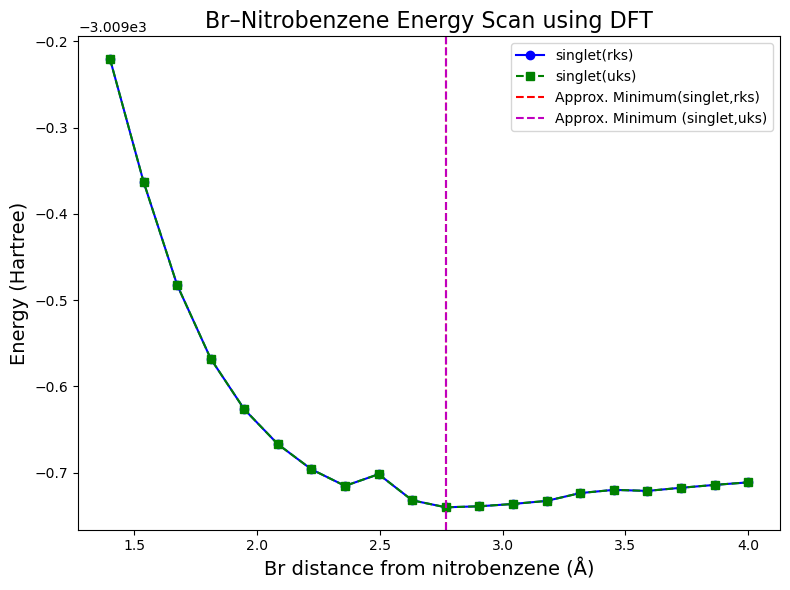

In [9]:
import matplotlib.pyplot as plt
# 4️⃣ Plot scan
plt.figure(figsize=(8,6))
plt.plot(br_distances, energies, marker='o', linestyle='-', color='b', label='singlet(rks)')
plt.plot(br_distances, energies_triplet, marker='s', linestyle='--', color='g', label='singlet(uks)')
plt.axvline(min_distance, color='r', linestyle='--', label='Approx. Minimum(singlet,rks)')
plt.axvline(min_distance_t, color='m', linestyle='--', label='Approx. Minimum (singlet,uks)')
plt.xlabel("Br distance from nitrobenzene (Å)", fontsize=14)
plt.ylabel("Energy (Hartree)", fontsize=14)
plt.title("Br–Nitrobenzene Energy Scan using DFT", fontsize=16)
plt.savefig("/Users/rmandern/code/md-cqed/br_nitrobenzene_wb97xd_uks.png", dpi=300)
# plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
print(energies)

[-3009.2201506185625, -3009.3626078100033, -3009.482306016178, -3009.5678384182957, -3009.626507872932, -3009.666936122999, -3009.6961081658073, -3009.7152620461316, -3009.7017320496043, -3009.7320089043797, -3009.740084138328, -3009.738923879835, -3009.7362171373325, -3009.732675737782, -3009.723599777275, -3009.719870051866, -3009.7210761370525, -3009.7174667360114, -3009.7141451555467, -3009.711179790409]
